In [1]:
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")

import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
import pandas as pd
import json
from pathlib import Path

In [2]:
def load_data(
    df_metadata,
    cart_position=None,
    pole_angle=None,
    seed=None,
):
    """
    Load intervention data from directories matching the specified criteria.
    
    Parameters can be single values or lists. If a parameter is None, it matches all values.
    
    Returns:
        pd.DataFrame: DataFrame with config info and episode data
    """

    # Convert single values to lists for uniform handling
    def to_list(val):
        if val is None:
            return None
        return val if isinstance(val, list) else [val]

    cart_position_list = to_list(cart_position)
    pole_angle_list = to_list(pole_angle)
    seed_list = to_list(seed)

    # Filter configs based on criteria
    filtered_configs = []
    for idx, config in df_metadata.iterrows():
        inital_state = config.get('initial_state')
        # Check each criterion
        if cart_position_list is not None and inital_state[
                0] not in cart_position_list:
            continue
        if pole_angle_list is not None and inital_state[
                1] not in pole_angle_list:
            continue
        if seed_list is not None and config.get('config_seed') not in seed_list:
            continue

        filtered_configs.append(config)

    print(f"Found {len(filtered_configs)} configurations")
    # Load episode data for each matching config
    results = []
    for config in tqdm(filtered_configs):
        directory = Path(config['directory'])
        episode_path = directory / "activations" / "episode_0000.pkl"

        if episode_path.exists():
            # Load the pickled episode data
            with open(episode_path, 'rb') as f:
                episode_data = pickle.load(f)

            # Unflatten the data structure
            episode_data = episode_data['data']
            for key, value in episode_data.items():

                if key == 'latent_states':
                    config[key] = value.squeeze()
                else:
                    config[key] = value

            results.append(config)

    return pd.DataFrame(results)


def flatten_dict(d, parent_key='', sep='_'):
    """
    Flatten a nested dictionary.
    
    Args:
        d: Dictionary to flatten
        parent_key: String to prepend to keys
        sep: Separator between nested keys
    
    Returns:
        Flattened dictionary
    """
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)


In [3]:
# Loop over all directories in the sweep logs
sweep_base_dir = Path("logs/28112025-initial_conditions_seeds_sweep")

all_metadata = []
for sweep_dir in sweep_base_dir.iterdir():
    if sweep_dir.is_dir():
        metadata_path = sweep_dir / "activations" / "episode_0000_metadata.json"
        if metadata_path.exists():
            with open(metadata_path, 'r') as f:
                metadata = json.load(f)
                # Flatten the nested metadata dictionary
                flattened_metadata = flatten_dict(metadata)
                # Add the directory path
                flattened_metadata['directory'] = str(sweep_dir)
                all_metadata.append(flattened_metadata)

print(f"Found {len(all_metadata)} configurations")
# Create DataFrame from flattened metadata

df_metadata = pd.DataFrame(all_metadata)


Found 165 configurations


In [4]:
df = load_data(
    df_metadata,
    cart_position=None,
    pole_angle=None,
    seed=None,
)


Found 165 configurations


100%|██████████| 165/165 [00:01<00:00, 138.06it/s]


In [5]:
df.head()

,seed,initial_state,checkpoint,task,episode_idx,episode_length,total_reward,timestamp,obs_type,directory,observations,actions,rewards,dones,latent_states,timesteps
0,3,"[-1.0, 0.6283185307179586]",ckpts/cartpole-swingup-3.pt,cartpole-swingup,0,500,835.713027,2025-11-28T17:51:57.265726,state,logs/28112025-initial_conditions_seeds_sweep/2...,"[[-1.0, 0.809017, 0.58778524, -0.0052817175, -...","[[1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1....","[1.1310687065124512, 1.1333321332931519, 1.137...","[False, False, False, False, False, False, Fal...","[[0.37310162, 0.03706175, 0.04121745, 0.047149...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
1,5,"[-1.0, 0.0]",ckpts/cartpole-swingup-3.pt,cartpole-swingup,0,500,963.945015,2025-11-28T18:04:27.182515,state,logs/28112025-initial_conditions_seeds_sweep/2...,"[[-1.0, 1.0, 0.0, -0.0052817175, -0.010729686]...","[[-0.9130028], [-0.64158756], [-0.50654215], [...","[1.2989814281463623, 1.4206653833389282, 1.454...","[False, False, False, False, False, False, Fal...","[[0.21577531, 0.10999941, 0.059098963, 0.10330...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
2,3,"[-1.0, 5.026548245743669]",ckpts/cartpole-swingup-3.pt,cartpole-swingup,0,500,774.939274,2025-11-28T17:53:19.517704,state,logs/28112025-initial_conditions_seeds_sweep/2...,"[[-1.0, 0.309017, -0.95105654, -0.0052817175, ...","[[1.0], [1.0], [0.6805563], [0.49439374], [0.2...","[0.8138473033905029, 0.7982663512229919, 0.876...","[False, False, False, False, False, False, Fal...","[[0.17223486, 0.057273608, 0.015006133, 0.4639...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
3,1,"[-1.0, 2.5132741228718345]",ckpts/cartpole-swingup-3.pt,cartpole-swingup,0,500,481.249575,2025-11-28T17:39:37.666827,state,logs/28112025-initial_conditions_seeds_sweep/2...,"[[-1.0, -0.809017, 0.58778524, -0.0052817175, ...","[[1.0], [1.0], [0.98401344], [0.6257322], [0.5...","[0.11805222928524017, 0.1127566322684288, 0.10...","[False, False, False, False, False, False, Fal...","[[0.7193506, 0.03957087, 0.028878266, 0.043282...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
4,4,"[1.0, 5.026548245743669]",ckpts/cartpole-swingup-3.pt,cartpole-swingup,0,500,920.019884,2025-11-28T18:03:52.879498,state,logs/28112025-initial_conditions_seeds_sweep/2...,"[[1.0, 0.309017, -0.95105654, -0.0052817175, -...","[[-1.0], [-0.80869275], [-0.60619825], [-0.395...","[0.8166788220405579, 0.8814069628715515, 0.927...","[False, False, False, False, False, False, Fal...","[[0.010755034, 0.055656478, 0.33169708, 0.4359...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."


In [5]:
df_pos0 = load_data(
    df_metadata,
    cart_position=0.,
    pole_angle=None,
    seed=None,
)

Found 55 configurations


100%|██████████| 55/55 [00:00<00:00, 308.58it/s]


Global R² Score: 0.9999


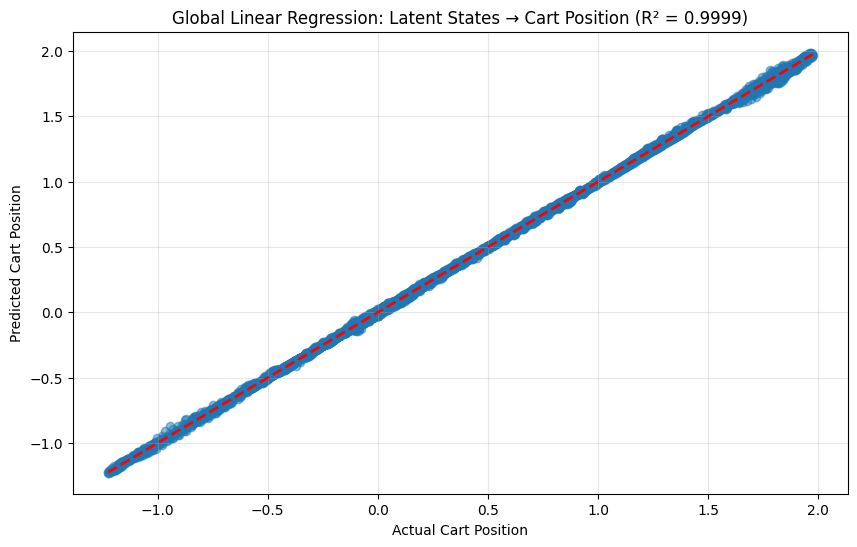


Number of unique pole angles: 11
Pole angle 0.0000: R² = 0.9656, n_samples = 2500
Pole angle 0.6283: R² = 0.9999, n_samples = 2500
Pole angle 1.2566: R² = 0.9998, n_samples = 2500
Pole angle 1.8850: R² = 0.9998, n_samples = 2500
Pole angle 2.5133: R² = 0.9998, n_samples = 2500
Pole angle 3.1416: R² = 0.9999, n_samples = 2500
Pole angle 3.7699: R² = 0.9997, n_samples = 2500
Pole angle 4.3982: R² = 0.9991, n_samples = 2500
Pole angle 5.0265: R² = 0.9998, n_samples = 2500
Pole angle 5.6549: R² = 0.9998, n_samples = 2500
Pole angle 6.2832: R² = 0.9524, n_samples = 2500


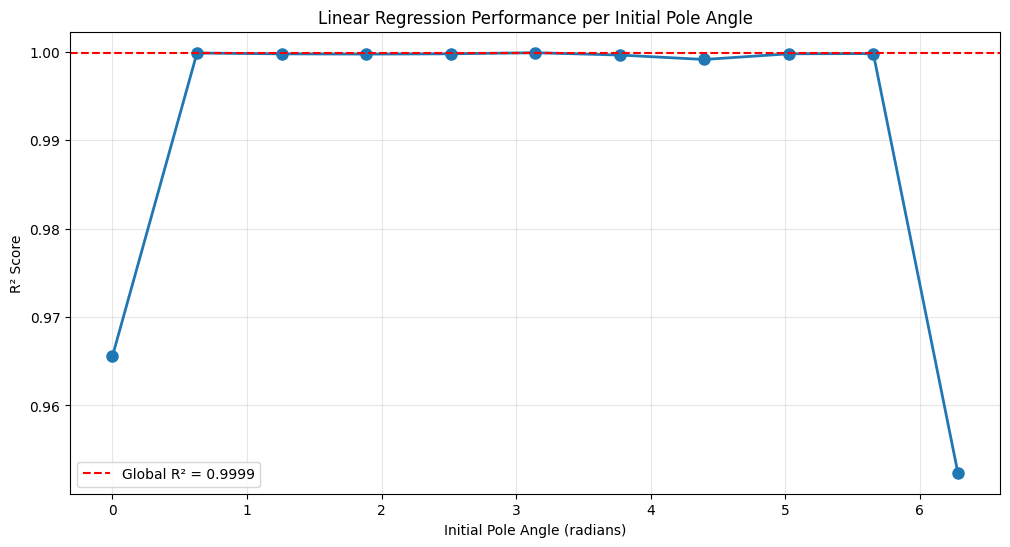

In [7]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score

df = df_pos0

# ============================================================================
# GLOBAL LINEAR REGRESSION (all initial conditions)
# ============================================================================

X_global = np.concatenate(df['latent_states'].tolist())
observations_global = np.concatenate(df['observations'].tolist())
y_global = observations_global[:, 0]

# Fit global linear regression
#lr_global = Ridge(fit_intercept=True, alpha=1.0)
lr_global = LinearRegression(fit_intercept=True)
lr_global.fit(X_global, y_global)
w_global = lr_global.coef_

# Predict and calculate R2
y_pred_global = lr_global.predict(X_global)
r2_global = r2_score(y_global, y_pred_global)

print(f"Global R² Score: {r2_global:.4f}")

# Plot global predictions vs actual
plt.figure(figsize=(10, 6))
plt.scatter(y_global, y_pred_global, alpha=0.5)
plt.plot([y_global.min(), y_global.max()],
         [y_global.min(), y_global.max()],
         'r--',
         lw=2)
plt.xlabel('Actual Cart Position')
plt.ylabel('Predicted Cart Position')
plt.title(
    f'Global Linear Regression: Latent States → Cart Position (R² = {r2_global:.4f})'
)
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================================
# LINEAR REGRESSION PER INITIAL POLE ANGLE
# ============================================================================

# Extract unique pole angles from initial_state (dimension 1)
df['pole_angle'] = df['initial_state'].apply(lambda x: x[1])
unique_pole_angles = sorted(df['pole_angle'].unique())

print(f"\nNumber of unique pole angles: {len(unique_pole_angles)}")

# Store results for each pole angle
results_per_angle = []

for pole_angle in unique_pole_angles:
    # Filter data for this pole angle
    df_angle = df[df['pole_angle'] == pole_angle]

    # Prepare data
    X_angle = np.concatenate(df_angle['latent_states'].tolist())
    observations_angle = np.concatenate(df_angle['observations'].tolist())
    y_angle = observations_angle[:, 0]

    # Fit linear regression
    lr_angle = Ridge(fit_intercept=True)
    lr_angle.fit(X_angle, y_angle)

    # Predict and calculate R2
    y_pred_angle = lr_angle.predict(X_angle)
    r2_angle = r2_score(y_angle, y_pred_angle)

    results_per_angle.append({
        'pole_angle': pole_angle,
        'r2': r2_angle,
        'w': lr_angle.coef_,
        'n_samples': len(y_angle)
    })

    print(
        f"Pole angle {pole_angle:.4f}: R² = {r2_angle:.4f}, n_samples = {len(y_angle)}"
    )

# Plot R² scores per pole angle
plt.figure(figsize=(12, 6))
pole_angles = [r['pole_angle'] for r in results_per_angle]
r2_scores = [r['r2'] for r in results_per_angle]
plt.plot(pole_angles, r2_scores, 'o-', linewidth=2, markersize=8)
plt.axhline(y=r2_global,
            color='r',
            linestyle='--',
            label=f'Global R² = {r2_global:.4f}')
plt.xlabel('Initial Pole Angle (radians)')
plt.ylabel('R² Score')
plt.title('Linear Regression Performance per Initial Pole Angle')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


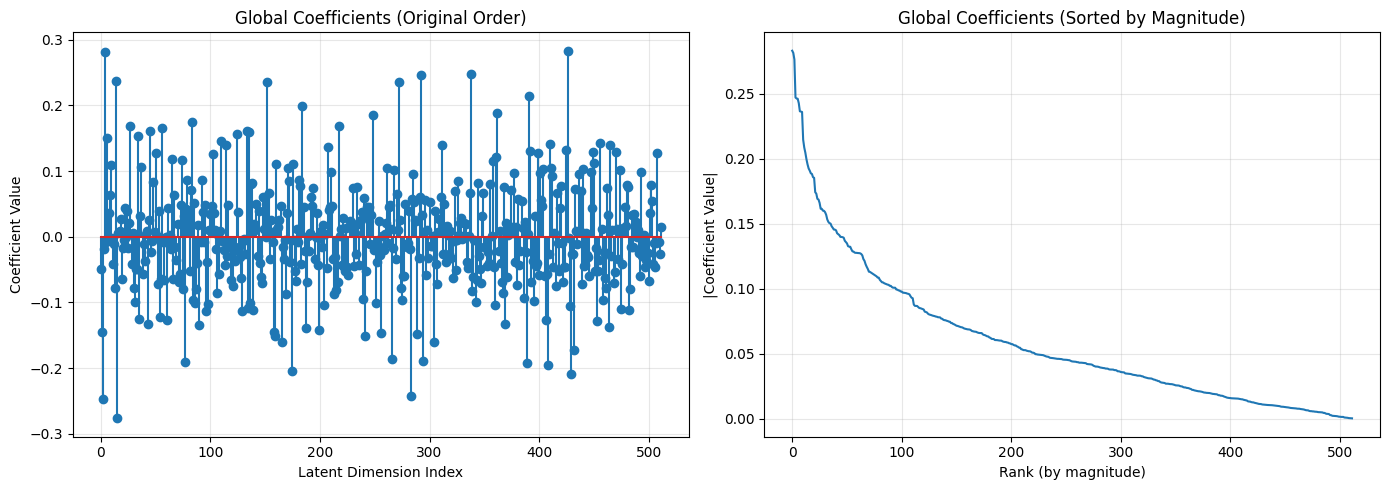

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: original order
axes[0].stem(w_global)
axes[0].set_xlabel('Latent Dimension Index')
axes[0].set_ylabel('Coefficient Value')
axes[0].set_title('Global Coefficients (Original Order)')
axes[0].grid(True, alpha=0.3)

# Right plot: sorted by magnitude
sorted_indices = np.argsort(np.abs(w_global))[::-1]
axes[1].plot(np.abs(w_global)[sorted_indices])
axes[1].set_xlabel('Rank (by magnitude)')
axes[1].set_ylabel('|Coefficient Value|')
axes[1].set_title('Global Coefficients (Sorted by Magnitude)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Comparing linear regression coefficients across pole angles:

Coefficient vector shape: (512,)
Number of angles: 11

Cosine similarity statistics (between pole angles):
  Mean similarity: 0.4962
  Std similarity: 0.2769
  Min similarity: -0.0833
  Max similarity: 0.9993

Cosine similarity with global model:
  Mean similarity: 0.2790
  Std similarity: 0.1348
  Min similarity: 0.1483
  Max similarity: 0.5409


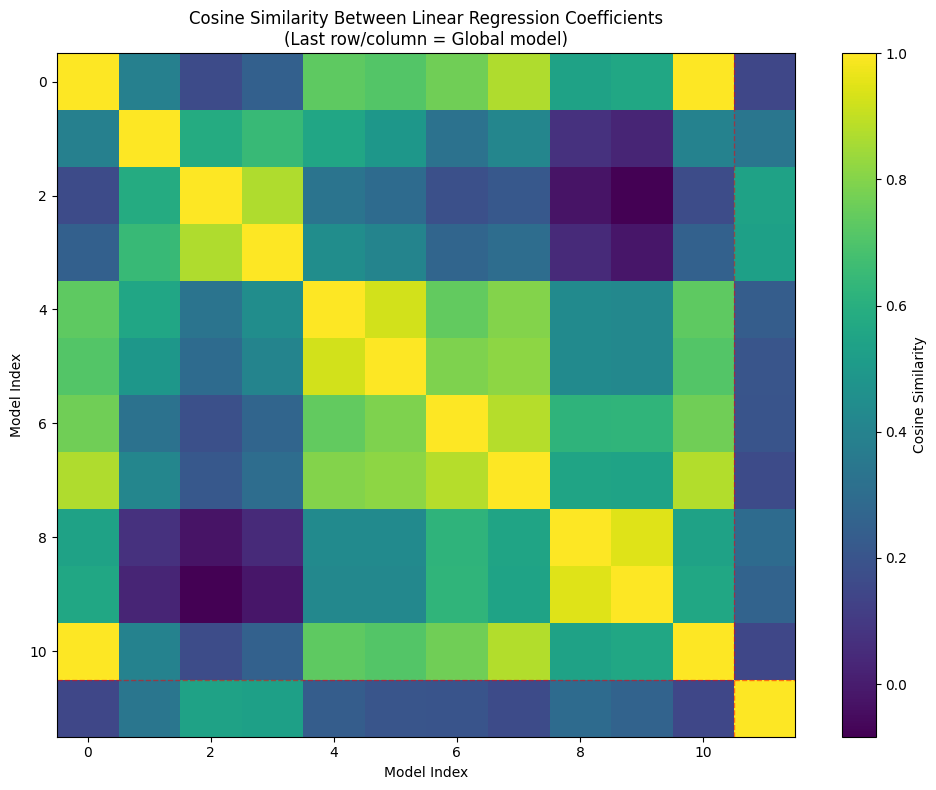

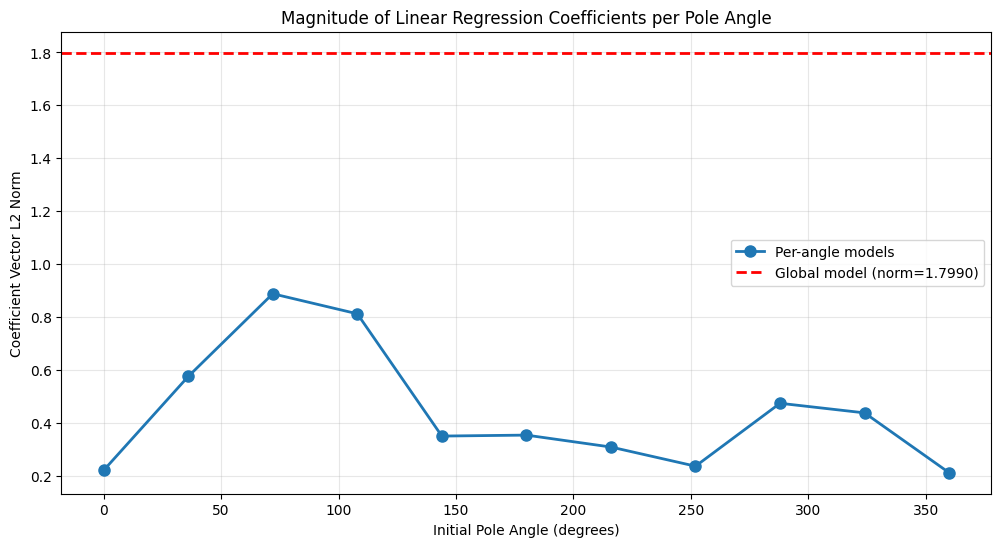

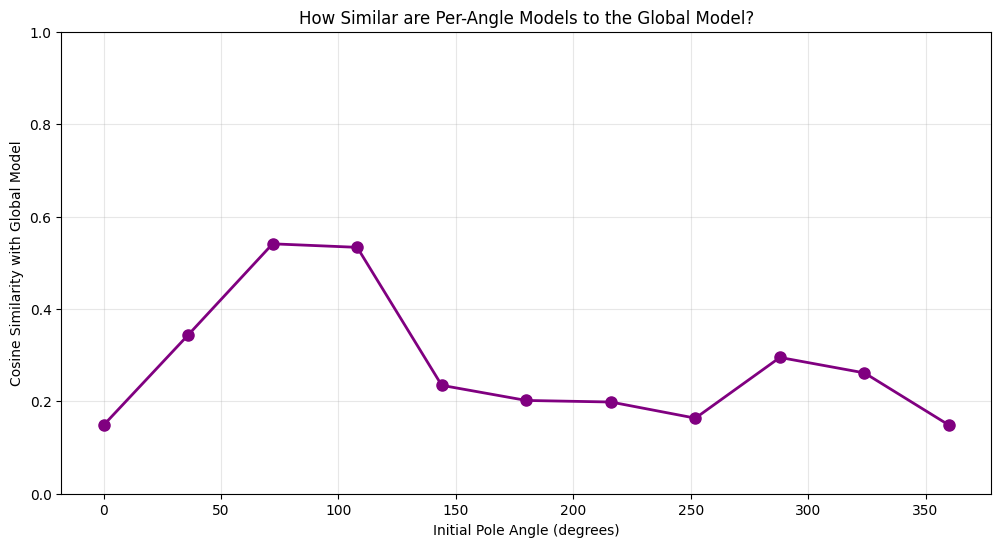

In [9]:
# Compare coefficients across different pole angles
print("Comparing linear regression coefficients across pole angles:\n")

# Extract all coefficient vectors
all_coefs = np.array([r['w'] for r in results_per_angle])
pole_angles = [r['pole_angle'] for r in results_per_angle]
pole_angles_deg = np.degrees(pole_angles)

# Add global coefficients for comparison
all_coefs_with_global = np.vstack([all_coefs, w_global.reshape(1, -1)])

# Calculate pairwise cosine similarities between coefficient vectors
from sklearn.metrics.pairwise import cosine_similarity

coef_similarities = cosine_similarity(all_coefs_with_global)

print(f"Coefficient vector shape: {all_coefs[0].shape}")
print(f"Number of angles: {len(pole_angles)}\n")

# Show statistics about coefficient similarity (excluding global)
print("Cosine similarity statistics (between pole angles):")
# Get upper triangle (excluding diagonal) for just the pole angle coefficients
upper_tri_indices = np.triu_indices(len(pole_angles), k=1)
similarities = coef_similarities[upper_tri_indices]
print(f"  Mean similarity: {similarities.mean():.4f}")
print(f"  Std similarity: {similarities.std():.4f}")
print(f"  Min similarity: {similarities.min():.4f}")
print(f"  Max similarity: {similarities.max():.4f}")

# Show similarity with global model
print("\nCosine similarity with global model:")
global_similarities = coef_similarities[-1, :-1]  # Last row, excluding itself
print(f"  Mean similarity: {global_similarities.mean():.4f}")
print(f"  Std similarity: {global_similarities.std():.4f}")
print(f"  Min similarity: {global_similarities.min():.4f}")
print(f"  Max similarity: {global_similarities.max():.4f}")

# Visualize coefficient similarity matrix
plt.figure(figsize=(10, 8))
im = plt.imshow(coef_similarities, cmap='viridis', aspect='auto')
plt.colorbar(im, label='Cosine Similarity')
plt.xlabel('Model Index')
plt.ylabel('Model Index')
plt.title(
    'Cosine Similarity Between Linear Regression Coefficients\n(Last row/column = Global model)'
)
# Add grid lines to separate global model
plt.axhline(y=len(pole_angles) - 0.5,
            color='red',
            linestyle='--',
            linewidth=1,
            alpha=0.5)
plt.axvline(x=len(pole_angles) - 0.5,
            color='red',
            linestyle='--',
            linewidth=1,
            alpha=0.5)
plt.tight_layout()
plt.show()

# Show coefficient magnitude comparison
coef_norms = np.linalg.norm(all_coefs, axis=1)
global_norm = np.linalg.norm(w_global)

plt.figure(figsize=(12, 6))
plt.plot(pole_angles_deg,
         coef_norms,
         'o-',
         linewidth=2,
         markersize=8,
         label='Per-angle models')
plt.axhline(y=global_norm,
            color='r',
            linestyle='--',
            linewidth=2,
            label=f'Global model (norm={global_norm:.4f})')
plt.xlabel('Initial Pole Angle (degrees)')
plt.ylabel('Coefficient Vector L2 Norm')
plt.title('Magnitude of Linear Regression Coefficients per Pole Angle')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Plot similarity with global model as a function of pole angle
plt.figure(figsize=(12, 6))
plt.plot(pole_angles_deg,
         global_similarities,
         'o-',
         linewidth=2,
         markersize=8,
         color='purple')
plt.xlabel('Initial Pole Angle (degrees)')
plt.ylabel('Cosine Similarity with Global Model')
plt.title('How Similar are Per-Angle Models to the Global Model?')
plt.grid(True, alpha=0.3)
plt.ylim([0, 1])
plt.show()


## Understanding the units of alpha in z = z + alpha * w

In [22]:
# Load the saved w_global
w_global_position = np.load(
    'sweeps/sweep_data/281125-latent_intervention_control/position_w_global.npy'
)

w_global_position_normalized = w_global_position / np.linalg.norm(
    w_global_position)

z = np.concatenate(df['latent_states'].tolist())

print(f"Loaded w_global shape: {w_global_position.shape}")
print(f"Loaded z shape: {z.shape}")

Loaded w_global shape: (512,)
Loaded z shape: (82500, 512)


In [24]:
assert np.linalg.norm(w_global_position_normalized) == 1

In [25]:
proj = z @ w_global_position_normalized

In [26]:
proj_mean = np.mean(proj)
proj_std = np.std(proj)
proj_min = np.min(proj)
proj_max = np.max(proj)

print(
    f"proj_mean: {proj_mean}, proj_std: {proj_std}, proj_min: {proj_min}, proj_max: {proj_max}"
)

proj_mean: -0.23484551906585693, proj_std: 0.29491913318634033, proj_min: -1.1220099925994873, proj_max: 0.8512733578681946


In [29]:
beta_values = [-2, -1, -0.5, 0.5, 1, 2]
alphas = [beta * proj_std for beta in beta_values]

In [30]:
alphas

[-0.5898382663726807,
 -0.29491913318634033,
 -0.14745956659317017,
 0.14745956659317017,
 0.29491913318634033,
 0.5898382663726807]

## save the results

In [ ]:
# # Save w_global to the specified directory
# import os

# save_dir = 'sweeps/sweep_data/281125-latent_intervention_control'
# os.makedirs(save_dir, exist_ok=True)
# save_path = os.path.join(save_dir, 'position_w_global.npy')
# np.save(save_path, w_global)

## Visualize initial conditions

In [10]:
from analysis.utils import reconstruct_cartpole_dmcontrol

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied



In [11]:
df_seed = df_pos0[df_pos0['seed'] == 1]
observations = np.concatenate(df_seed['observations'].tolist())[::500]

frames = []
for state in observations:
    frame = reconstruct_cartpole_dmcontrol(state.reshape(1, -1),
                                           height=240,
                                           width=320,
                                           camera_id=0,
                                           save_video=False)
    frames.append(frame)


100%|██████████| 1/1 [00:00<00:00,  9.51it/s]


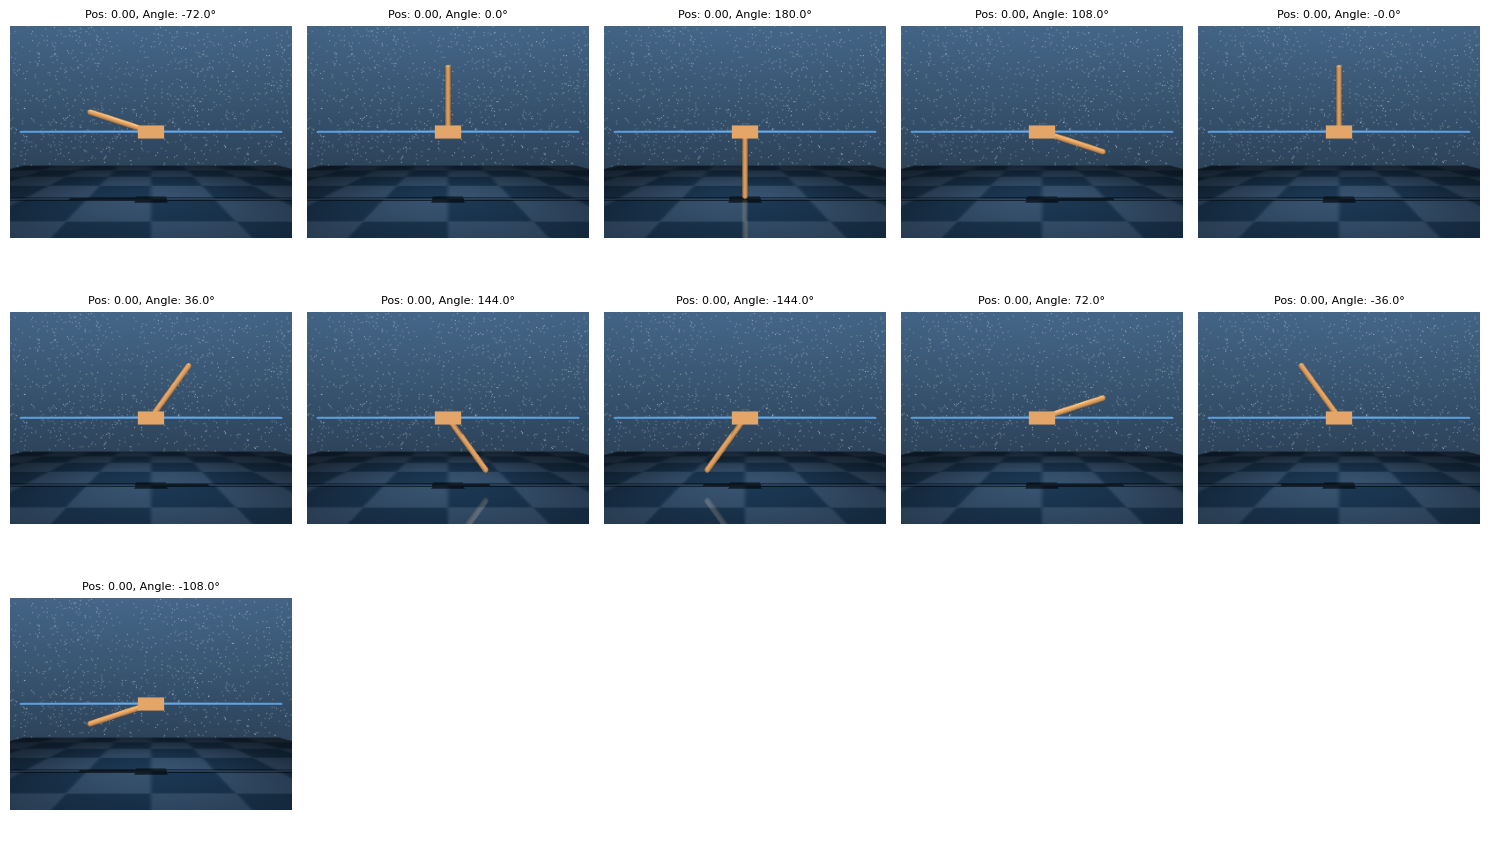

In [12]:
# Plot all frames in a grid, 5 per row
num_frames = len(frames)
num_cols = 5
num_rows = (num_frames + num_cols - 1) // num_cols  # Ceiling division

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3 * num_rows))
axes = axes.flatten() if num_rows > 1 else [axes] if num_cols == 1 else axes

for idx, (frame, state) in enumerate(zip(frames, observations)):
    # Extract state components
    cart_pos = state[0]
    cos_theta = state[1]
    sin_theta = state[2]

    # Compute angle in degrees
    angle_rad = np.arctan2(sin_theta, cos_theta)
    angle_deg = np.degrees(angle_rad)

    # Plot frame
    axes[idx].imshow(frame[0])  # frame is a list with one element
    axes[idx].set_title(f'Pos: {cart_pos:.2f}, Angle: {angle_deg:.1f}°',
                        fontsize=8)
    axes[idx].axis('off')

# Hide any unused subplots
for idx in range(num_frames, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()